# Traffic Network Visualization
**I-95 / I-66 corridor — Northern Virginia / Washington D.C.**

Three outputs are generated:
1. `network_static.png` – static network + mean traffic map
2. `traffic_heatmaps.png` – hourly/weekday pattern heatmaps
3. `sensor_map.html` – interactive Folium geographic map
4. `traffic_animation.html` – Plotly animated traffic (typical week, Mon–Fri 00:00–23:00)

> **Note on geographic positions**: sensor coordinates are *approximate*, derived from
> MDS of the adjacency matrix and mapped onto the known I-95 / I-66 route geometry.
> They reflect the network topology correctly but may not match the exact GPS locations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import networkx as nx
import folium
import plotly.graph_objects as go
from scipy.io import loadmat
from sklearn.manifold import MDS
import warnings, os
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110


In [2]:
mat  = loadmat("traffic_dataset.mat")
X_tr = np.array([m.toarray() for m in mat['tra_X_tr'][0]], dtype=np.float32)
X_te = np.array([m.toarray() for m in mat['tra_X_te'][0]], dtype=np.float32)
Y_tr = mat['tra_Y_tr'].T.astype(np.float32)
Y_te = mat['tra_Y_te'].T.astype(np.float32)
adj  = mat['tra_adj_mat'].astype(np.float32)

X = np.concatenate([X_tr, X_te], axis=0)   # [2101, 36, 48]
Y = np.concatenate([Y_tr, Y_te], axis=0)   # [2101, 36]
n_time, n_sensors = Y.shape

print(f"X: {X.shape}  Y: {Y.shape}  adj: {adj.shape}")
print(f"Y range: [{Y.min():.3f}, {Y.max():.3f}]  (pre-normalised to [0,1])")


X: (2101, 36, 48)  Y: (2101, 36)  adj: (36, 36)
Y range: [0.000, 1.000]  (pre-normalised to [0,1])


## Per-sensor static features & time index

In [3]:
feats   = X[0]                                      # [36, 48] first time-step
road_id = np.argmax(feats[:, 44:48], axis=1)        # 0-3
dir_id  = np.argmax(feats[:, 40:44], axis=1)        # 0-3
lanes   = feats[:, 39].astype(int)                  # 1-5

weekday = np.argmax(X[:, 0, 10:15], axis=1)         # 0=Mon … 4=Fri
hour    = np.argmax(X[:, 0, 15:39], axis=1)         # 0=midnight … 23=11 pm

DAY_NAMES   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
ROAD_LABELS = ['Road-0 (I-95 main)', 'Road-1 (I-66)',
               'Road-2 (connector N)', 'Road-3 (connector S)']
ROAD_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

print("Sensor distribution per road group:")
for r in range(4):
    m = road_id == r
    print(f"  {ROAD_LABELS[r]:26s}: {m.sum():2d} sensors  "
          f"dirs={np.unique(dir_id[m]).tolist()}  lanes={np.unique(lanes[m]).tolist()}")


Sensor distribution per road group:
  Road-0 (I-95 main)        : 15 sensors  dirs=[0, 1, 2]  lanes=[1, 2, 3, 4]
  Road-1 (I-66)             : 11 sensors  dirs=[0, 1]  lanes=[3, 4, 5]
  Road-2 (connector N)      :  5 sensors  dirs=[3]  lanes=[2, 4, 5]
  Road-3 (connector S)      :  5 sensors  dirs=[3]  lanes=[3, 4]


## Typical-week traffic (mean per weekday × hour)

In [4]:
typical = np.zeros((5, 24, n_sensors))
counts  = np.zeros((5, 24))
for t in range(n_time):
    wd, h = weekday[t], hour[t]
    typical[wd, h] += Y[t]
    counts[wd, h]  += 1
for wd in range(5):
    for h in range(24):
        if counts[wd, h] > 0:
            typical[wd, h] /= counts[wd, h]

frames_vol   = typical.reshape(120, n_sensors)           # [120, 36]
frame_labels = [f"{DAY_NAMES[wd]} {h:02d}:00"
                for wd in range(5) for h in range(24)]   # 120 labels

peak_fi  = int(frames_vol.mean(axis=1).argmax())
trough_fi = int(frames_vol.mean(axis=1).argmin())
print(f"Peak traffic frame   : {frame_labels[peak_fi]}")
print(f"Lowest traffic frame : {frame_labels[trough_fi]}")


Peak traffic frame   : Fri 12:00
Lowest traffic frame : Tue 23:00


## Geographic coordinates — two-hub topology
The network has **two geographic hubs** connected by a 13 km I-66 segment:

**Hub A — Pentagon / I-66 / I-395 junction** (~38.870 N, 77.063 W)
Sensors S00 S04 S14 S21 S25 cluster here where I-66 terminates into I-395.

| Chain from Hub A | Sensors |
|---|---|
| I-395 SB → Alexandria (D0) | S00→S01→S02→S03 |
| I-395/I-95 NB → Woodbridge (D1) | S14→S13→S10→S08→S09→S12→S11 |
| I-395 HOV ramp toward DC (D2) | S25→S22→S23→S24 |
| I-66 EB (D0), 3 stops west | S04→S05→**S06**→S07 |
| I-66 WB (D1), 6 stops west | S21→S20→**S19**→S18→S17→S16→S15 |

**Hub B — I-66 / I-495 interchange** (~38.892 N, 77.228 W)
Sensors S26 S29 S31 at the Dunn Loring interchange. S06 and S19 (I-66) pass through here.

| Chain from Hub B | Sensors |
|---|---|
| I-495 NW → McLean (R2) | S29→S35→S28→S27 |
| I-495 SW → Springfield / I-95 (R3) | S31→S34→S33→S30/S32 |


In [5]:
# Topology-aware sensor positions — two geographic hubs + chains
#
# HUB A  Pentagon / I-66 / I-395 junction  (~38.870 N, 77.063 W)
#   S00 S14 S25  I-395/I-95 at I-66 interchange
#   S04 S21      I-66 eastern terminus
#   Chains from Hub A:
#     D0 south  S00→01→02→03    I-395 SB toward Alexandria
#     D1 south  S14→13→10→08→09→12→11  I-395/I-95 toward Woodbridge
#     D2 north  S25→22→23→24   I-395 HOV / ramp corridor toward DC
#     I-66 west S04→05→06→07   I-66 EB (3 more stops, ends ~Fairfax)
#     I-66 west S21→20→19→…→15 I-66 WB (6 more stops, ends ~Manassas)
#
# HUB B  I-66 / I-495 interchange  (~38.892 N, 77.227 W)
#   S26 S29 S31  I-495 at I-66 junction  (13 km west of Hub A on I-66)
#   Also: S06 S19 (I-66 through-sensors at this interchange)
#   Chains from Hub B:
#     R2 NW  S29→S35→S28→S27  I-495 toward McLean
#     R3 SW  S31→S34→S33→S30/S32  I-495 toward Springfield / I-95

SENSOR_LAT = {
    # ── HUB A: Pentagon / I-66 / I-395 junction (Arlington VA) ──────────────
     0: 38.869,   # S00 R0-D0  I-395 NB lane, near I-66 ramp
    14: 38.868,   # S14 R0-D1  I-395 SB lane, near I-66 ramp
    25: 38.871,   # S25 R0-D2  I-395 / I-66 HOV connector hub
     4: 38.873,   # S04 R1-D0  I-66 EB, eastern terminus
    21: 38.871,   # S21 R1-D1  I-66 WB, eastern terminus

    # ── I-395 SB chain (D0) — going south toward Alexandria ──────────────────
     1: 38.845,   # near Shirlington
     2: 38.820,   # near King St
     3: 38.793,   # near Braddock Rd / I-395 end

    # ── I-395/I-95 NB chain (D1) — going south toward Woodbridge ─────────────
    13: 38.846,   # near Shirlington
    10: 38.821,   # near King St
     8: 38.793,   # near Braddock Rd
     9: 38.769,   # near Franconia-Springfield Pkwy
    12: 38.743,   # near Lorton
    11: 38.715,   # near Woodbridge north

    # ── I-395 HOV / ramp corridor going north toward DC (D2) ─────────────────
    22: 38.876,   # near Columbia Pike / I-395 (2-lane HOV)
    23: 38.875,   # near Glebe Rd approach  (2-lane)
    24: 38.869,   # near I-66 / I-395 ramp end  (1-lane, end of HOV)

    # ── I-66 EB chain (D0) going west — Hub A → Hub B → beyond ───────────────
     5: 38.884,   # near Glebe Rd / I-66
     6: 38.892,   # at Hub B — I-66 / I-495 interchange (EB lane)
     7: 38.878,   # near Rt 123 Fairfax, west of I-495

    # ── I-66 WB chain (D1) going west — Hub A → Hub B → Manassas ─────────────
    20: 38.882,   # near Glebe Rd / I-66
    19: 38.890,   # at Hub B — I-66 / I-495 interchange (WB lane)
    18: 38.876,   # near Rt 123 Fairfax
    17: 38.862,   # near Rt 28 / Centreville
    16: 38.828,   # near I-234 / Manassas north
    15: 38.789,   # near I-66 western terminus / Manassas

    # ── HUB B: I-66 / I-495 interchange (Dunn Loring / Merrifield) ──────────
    26: 38.894,   # S26 R2  I-495 NB at I-66 junction
    29: 38.896,   # S29 R2  I-495, just north of junction
    31: 38.889,   # S31 R3  I-495 SB at I-66 junction

    # ── I-495 NW toward McLean (R2 chain) ─────────────────────────────────────
    35: 38.907,   # near Rt 7 / Leesburg Pike interchange
    28: 38.921,   # near Tysons Corner (Rt 123 / I-495)
    27: 38.937,   # near Old Dominion Dr / McLean

    # ── I-495 SW toward Springfield / I-95 (R3 chain) ─────────────────────────
    34: 38.871,   # near Rt 50 / Arlington Blvd
    33: 38.847,   # near Rt 236 / Little River Turnpike (Annandale)
    30: 38.813,   # near I-495 / Braddock Rd (Springfield north)
    32: 38.814,   # parallel to S30 (opposite direction)
}

SENSOR_LON = {
    # ── HUB A ────────────────────────────────────────────────────────────────
     0: -77.051,  14: -77.056,  25: -77.063,
     4: -77.069,  21: -77.074,

    # ── I-395 SB (D0) ─────────────────────────────────────────────────────────
     1: -77.063,   2: -77.078,   3: -77.095,

    # ── I-395/I-95 NB (D1) ────────────────────────────────────────────────────
    13: -77.061,  10: -77.076,   8: -77.093,   9: -77.114,  12: -77.140,  11: -77.168,

    # ── I-395 HOV/ramp toward DC (D2) ─────────────────────────────────────────
    22: -77.044,  23: -77.034,  24: -77.059,

    # ── I-66 EB (D0) ──────────────────────────────────────────────────────────
     5: -77.109,   6: -77.226,   7: -77.300,

    # ── I-66 WB (D1) ──────────────────────────────────────────────────────────
    20: -77.112,  19: -77.229,  18: -77.302,  17: -77.409,  16: -77.459,  15: -77.499,

    # ── HUB B ────────────────────────────────────────────────────────────────
    26: -77.232,  29: -77.226,  31: -77.235,

    # ── I-495 NW to McLean (R2) ───────────────────────────────────────────────
    35: -77.215,  28: -77.202,  27: -77.186,

    # ── I-495 SW to Springfield (R3) ──────────────────────────────────────────
    34: -77.219,  33: -77.208,  30: -77.193,  32: -77.196,
}

lat_arr = np.array([SENSOR_LAT[i] for i in range(n_sensors)])
lon_arr = np.array([SENSOR_LON[i] for i in range(n_sensors)])

print(f"Lat range: [{lat_arr.min():.3f}, {lat_arr.max():.3f}]")
print(f"Lon range: [{lon_arr.min():.3f}, {lon_arr.max():.3f}]")
print("Hub sensors (all near Pentagon/I-66/I-395 junction):")
hub = [0, 4, 14, 21, 25, 26, 29, 31]
for s in hub:
    print(f"  S{s:02d}: ({lat_arr[s]:.3f}, {lon_arr[s]:.3f})")


Lat range: [38.715, 38.937]
Lon range: [-77.499, -77.034]
Hub sensors (all near Pentagon/I-66/I-395 junction):
  S00: (38.869, -77.051)
  S04: (38.873, -77.069)
  S14: (38.868, -77.056)
  S21: (38.871, -77.074)
  S25: (38.871, -77.063)
  S26: (38.894, -77.232)
  S29: (38.896, -77.226)
  S31: (38.889, -77.235)


## Static network visualisation

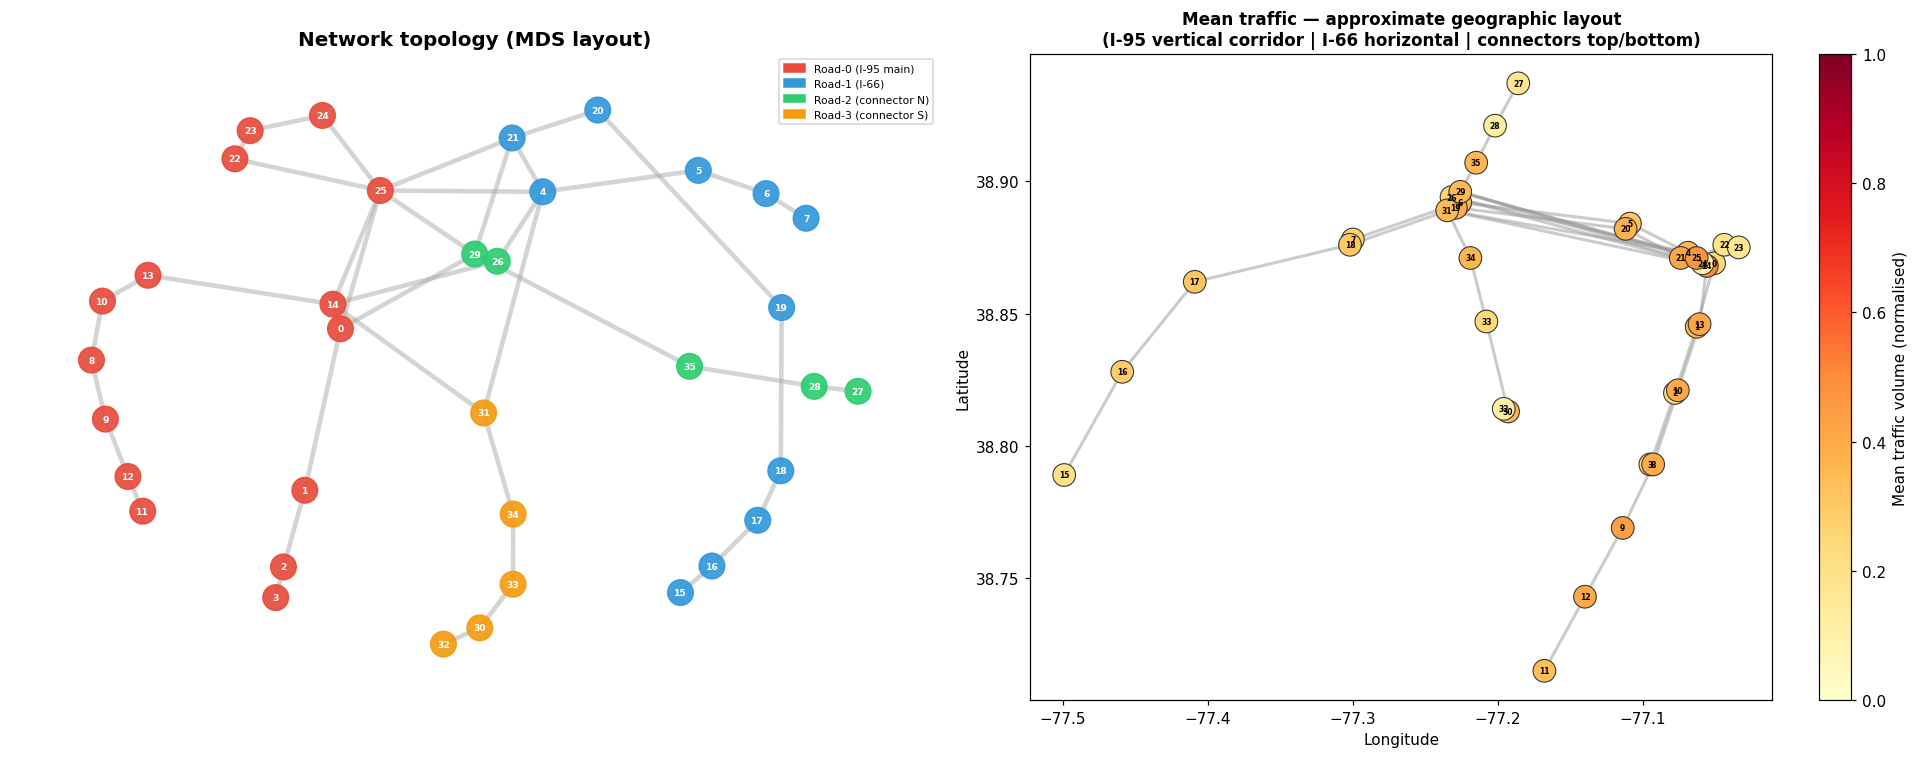

Saved network_static.png


In [6]:
# MDS layout — used only for the topology panel in the static plot
from sklearn.manifold import MDS
adj_sym  = (adj + adj.T) / 2
max_w    = adj_sym[adj_sym > 0].max()
dist_mat = np.where(adj_sym > 0, max_w / adj_sym, max_w * 8)
np.fill_diagonal(dist_mat, 0)
mds = MDS(n_components=2, dissimilarity='precomputed',
          random_state=42, n_init=4, normalized_stress='auto')
pos_mds = mds.fit_transform(dist_mat)

G = nx.Graph()
for i in range(n_sensors):
    G.add_node(i)
for i in range(n_sensors):
    for j in range(i + 1, n_sensors):
        if adj[i, j] > 0.05:
            G.add_edge(i, j, weight=float(adj[i, j]))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Panel 1: MDS topology ─────────────────────────────────────────────────────
ax = axes[0]
pos_dict    = {i: (pos_mds[i, 0], pos_mds[i, 1]) for i in range(n_sensors)}
node_colors = [ROAD_COLORS[road_id[i]] for i in range(n_sensors)]
edge_widths = [G[u][v]['weight'] * 3 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos_dict, ax=ax, width=edge_widths,
                       edge_color='#aaaaaa', alpha=0.5)
nx.draw_networkx_nodes(G, pos_dict, ax=ax, node_color=node_colors,
                       node_size=280, alpha=0.92)
nx.draw_networkx_labels(G, pos_dict, ax=ax,
                        font_size=6, font_color='white', font_weight='bold')
legend_h = [mpatches.Patch(color=ROAD_COLORS[r], label=ROAD_LABELS[r])
            for r in range(4)]
ax.legend(handles=legend_h, loc='upper right', fontsize=7)
ax.set_title("Network topology (MDS layout)", fontsize=13, fontweight='bold')
ax.axis('off')

# ── Panel 2: Mean traffic on approx. geo layout ───────────────────────────────
ax = axes[1]
mean_vol = Y.mean(axis=0)
for i in range(n_sensors):
    for j in range(i + 1, n_sensors):
        w = float(adj[i, j])
        if w > 0.08:
            ax.plot([lon_arr[i], lon_arr[j]], [lat_arr[i], lat_arr[j]],
                    color='#999999', alpha=w * 0.5, linewidth=w * 2.0, zorder=1)
sc = ax.scatter(lon_arr, lat_arr, c=mean_vol, cmap='YlOrRd', s=220,
                vmin=0, vmax=1, zorder=5, edgecolors='#333333', linewidth=0.7)
for i in range(n_sensors):
    ax.annotate(str(i), (lon_arr[i], lat_arr[i]),
                fontsize=5, ha='center', va='center',
                color='black', fontweight='bold', zorder=6)
plt.colorbar(sc, ax=ax, label='Mean traffic volume (normalised)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title("Mean traffic — approximate geographic layout\n"
             "(I-95 vertical corridor | I-66 horizontal | connectors top/bottom)",
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("network_static.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved network_static.png")


## Traffic pattern heatmaps

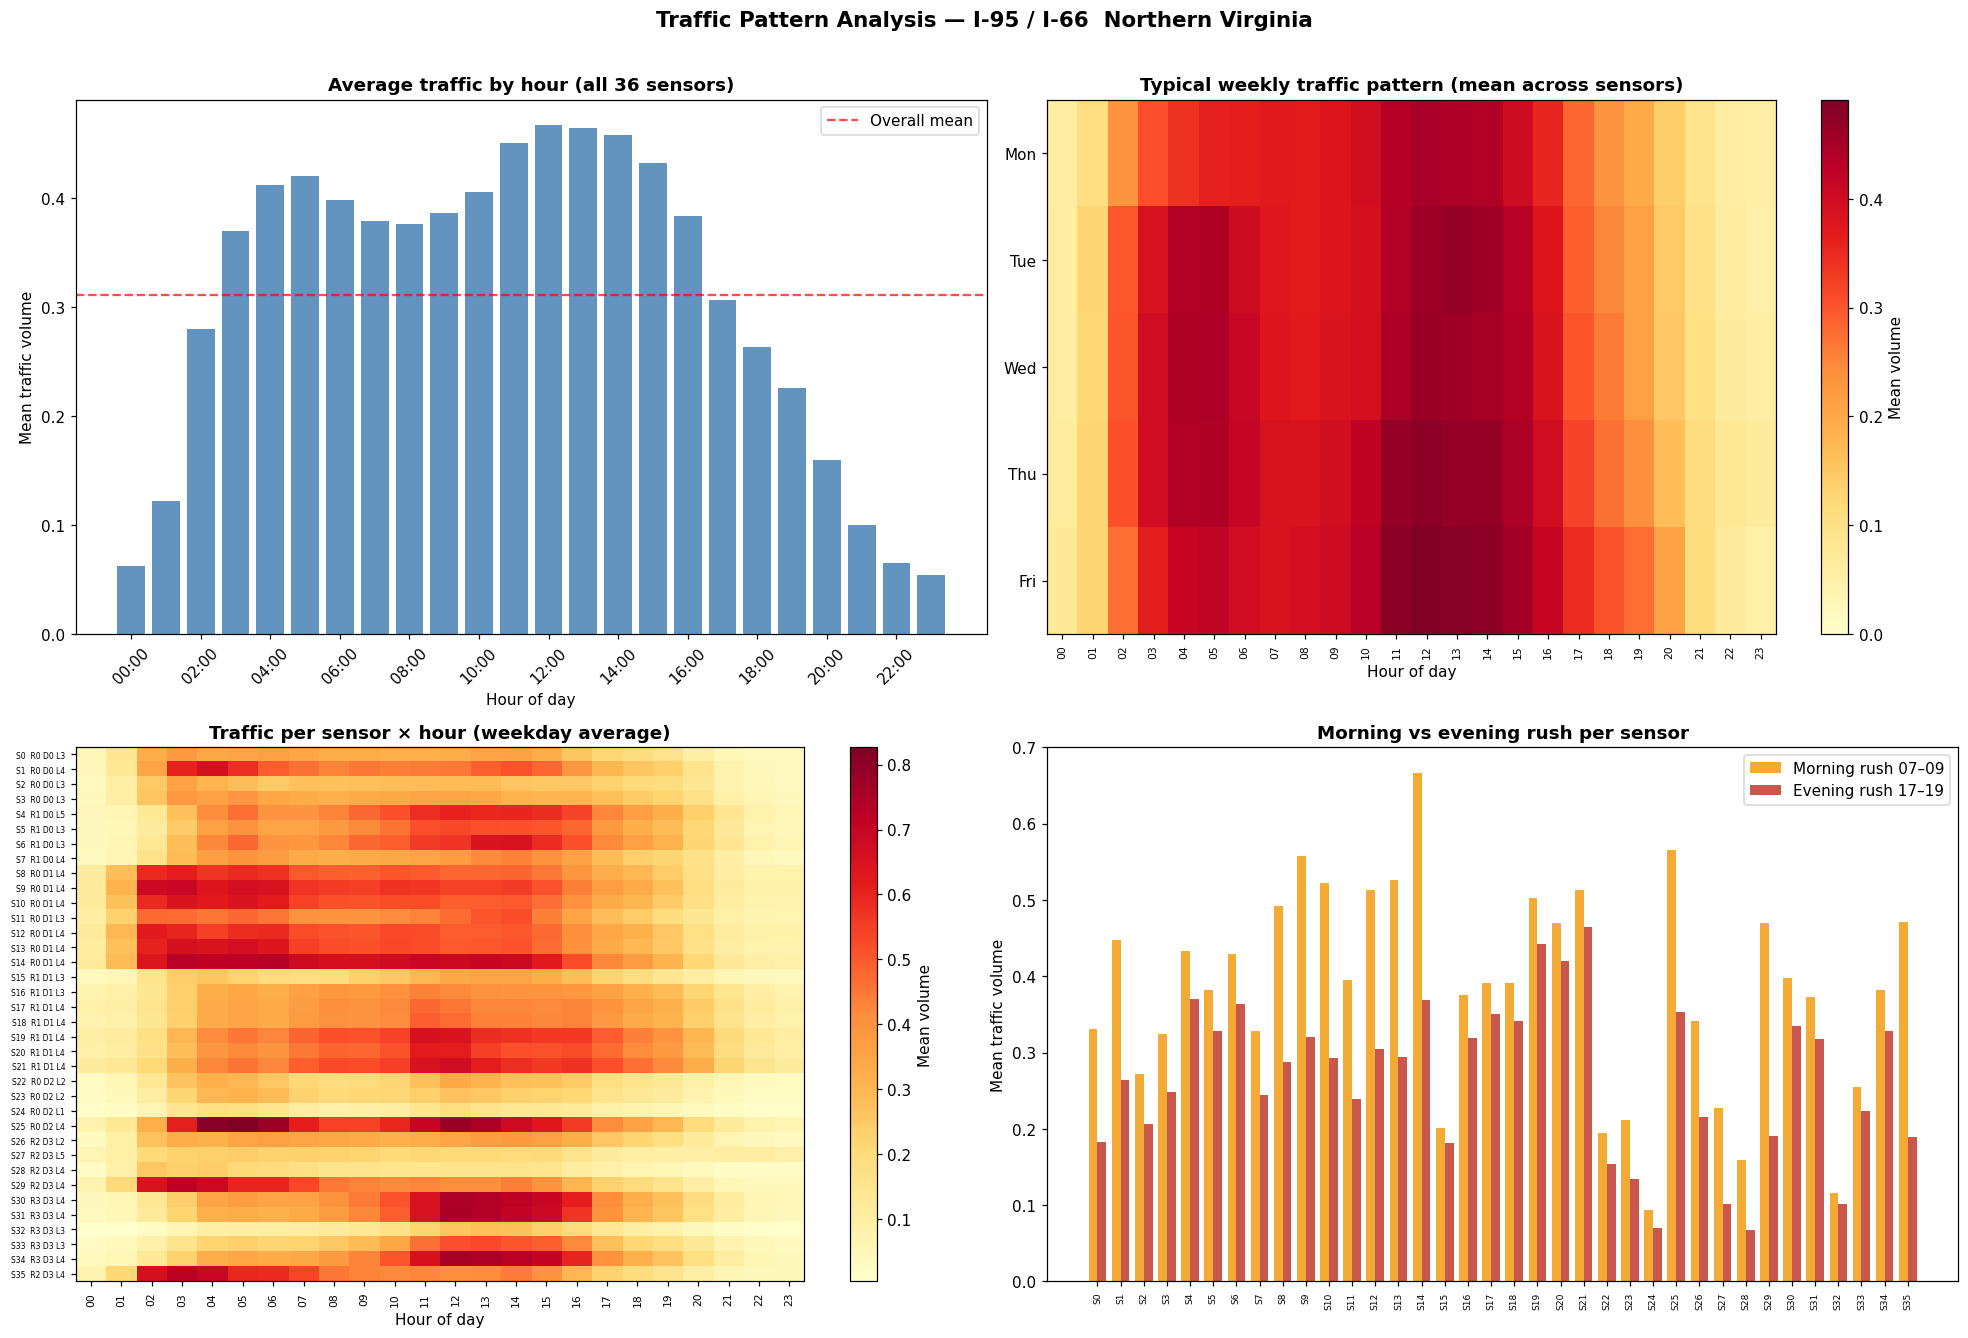

Saved traffic_heatmaps.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── 1. Hourly average (all sensors) ──────────────────────────────────────────
ax = axes[0, 0]
mean_h = np.array([Y[hour == h].mean() if (hour == h).any() else 0
                   for h in range(24)])
ax.bar(range(24), mean_h, color='steelblue', alpha=0.85)
ax.axhline(Y.mean(), color='red', linestyle='--', alpha=0.7, label='Overall mean')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean traffic volume')
ax.set_title('Average traffic by hour (all 36 sensors)', fontweight='bold')
ax.legend()

# ── 2. Weekday × hour heatmap ─────────────────────────────────────────────────
ax = axes[0, 1]
typical_agg = typical.mean(axis=2)   # [5, 24]
im = ax.imshow(typical_agg, aspect='auto', cmap='YlOrRd', vmin=0, vmax=typical_agg.max())
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)], rotation=90, fontsize=7)
ax.set_yticks(range(5)); ax.set_yticklabels(DAY_NAMES)
ax.set_xlabel('Hour of day')
ax.set_title('Typical weekly traffic pattern (mean across sensors)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean volume')

# ── 3. Sensor × hour heatmap ─────────────────────────────────────────────────
ax = axes[1, 0]
sensor_hour = typical.mean(axis=0).T   # [36, 24]
im2 = ax.imshow(sensor_hour, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)], rotation=90, fontsize=7)
ytick_labels = [f'S{i}  R{road_id[i]} D{dir_id[i]} L{lanes[i]}' for i in range(n_sensors)]
ax.set_yticks(range(n_sensors)); ax.set_yticklabels(ytick_labels, fontsize=5)
ax.set_xlabel('Hour of day')
ax.set_title('Traffic per sensor × hour (weekday average)', fontweight='bold')
plt.colorbar(im2, ax=ax, label='Mean volume')

# ── 4. Morning vs evening rush ────────────────────────────────────────────────
ax = axes[1, 1]
morning = typical[:, 7:10, :].mean(axis=(0, 1))
evening = typical[:, 17:20, :].mean(axis=(0, 1))
x = np.arange(n_sensors); w = 0.38
ax.bar(x - w/2, morning, w, label='Morning rush 07–09', color='#f39c12', alpha=0.85)
ax.bar(x + w/2, evening, w, label='Evening rush 17–19', color='#c0392b', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'S{i}' for i in range(n_sensors)], rotation=90, fontsize=6)
ax.set_ylabel('Mean traffic volume'); ax.legend()
ax.set_title('Morning vs evening rush per sensor', fontweight='bold')

plt.suptitle('Traffic Pattern Analysis — I-95 / I-66  Northern Virginia',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("traffic_heatmaps.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved traffic_heatmaps.png")


## Folium interactive geographic map

In [8]:
mean_vol = Y.mean(axis=0)
norm     = mcolors.Normalize(vmin=mean_vol.min(), vmax=mean_vol.max())
cmap     = cm.get_cmap('YlOrRd')

m = folium.Map(location=[38.82, -77.22], zoom_start=11,
               tiles='CartoDB positron')

# ── Edges ──────────────────────────────────────────────────────────────────────
for i in range(n_sensors):
    for j in range(i + 1, n_sensors):
        w = float(adj[i, j])
        if w > 0.08:
            folium.PolyLine(
                locations=[[lat_arr[i], lon_arr[i]], [lat_arr[j], lon_arr[j]]],
                weight=max(1.0, w * 5), color='#666666', opacity=0.45
            ).add_to(m)

# ── Sensor markers ─────────────────────────────────────────────────────────────
for i in range(n_sensors):
    vol       = float(mean_vol[i])
    fill_hex  = mcolors.to_hex(cmap(norm(vol)))
    rush_m    = float(typical[:, 7:10, i].mean())
    rush_e    = float(typical[:, 17:20, i].mean())
    off_peak  = float(typical[:, 1:5, i].mean())

    popup_html = (
        f"<div style='font-family:monospace;font-size:12px;min-width:200px'>"
        f"<b>Sensor {i}</b><br>"
        f"Road: <b>{ROAD_LABELS[road_id[i]]}</b><br>"
        f"Direction class: <b>{dir_id[i]}</b> | Lanes: <b>{lanes[i]}</b><br>"
        f"<hr style='margin:4px 0'>"
        f"Mean traffic: <b>{vol:.3f}</b><br>"
        f"Morning rush (07–09): <b>{rush_m:.3f}</b><br>"
        f"Evening rush (17–19): <b>{rush_e:.3f}</b><br>"
        f"Off-peak (01–04):      <b>{off_peak:.3f}</b>"
        f"</div>"
    )

    folium.CircleMarker(
        location=[lat_arr[i], lon_arr[i]],
        radius=6 + vol * 12,
        color='#222222', weight=1.2,
        fill=True, fill_color=fill_hex, fill_opacity=0.88,
        popup=folium.Popup(popup_html, max_width=230),
        tooltip=f"S{i} | Vol:{vol:.2f} | {ROAD_LABELS[road_id[i]]}",
    ).add_to(m)

    folium.Marker(
        location=[lat_arr[i], lon_arr[i]],
        icon=folium.DivIcon(
            html=(f'<div style="font-size:7px;font-weight:bold;color:white;'
                  f'text-align:center;line-height:14px">{i}</div>'),
            icon_size=(14, 14), icon_anchor=(7, 7),
        )
    ).add_to(m)

m.save("sensor_map.html")
print("Saved  sensor_map.html  — open in a browser for the interactive map")
m


Saved  sensor_map.html  — open in a browser for the interactive map


## Plotly animated traffic map
**Typical week pattern**: 5 days × 24 hours = 120 frames.
Node **colour** and **size** encode traffic volume. Use the slider or Play button.


In [9]:
# ── Static edge trace ─────────────────────────────────────────────────────────
e_lat, e_lon = [], []
for i in range(n_sensors):
    for j in range(i + 1, n_sensors):
        if adj[i, j] > 0.08:
            e_lat += [lat_arr[i], lat_arr[j], None]
            e_lon += [lon_arr[i], lon_arr[j], None]

edge_trace = go.Scattermapbox(
    lat=e_lat, lon=e_lon, mode='lines',
    line=dict(width=1.5, color='rgba(80,80,80,0.35)'),
    hoverinfo='none', showlegend=False,
)

def node_trace(vol):
    return go.Scattermapbox(
        lat=lat_arr.tolist(), lon=lon_arr.tolist(),
        mode='markers+text',
        marker=dict(
            size=(5 + vol * 20).tolist(),
            color=vol.tolist(),
            colorscale='YlOrRd', cmin=0, cmax=1,
            colorbar=dict(title='Traffic<br>Volume', x=0.02,
                          thickness=14, len=0.6),
            opacity=0.9,
        ),
        text=[str(i) for i in range(n_sensors)],
        textfont=dict(size=7, color='black'),
        textposition='middle center',
        hovertext=[
            f"Sensor {i}<br>{ROAD_LABELS[road_id[i]]}<br>"
            f"Dir-{dir_id[i]}  Lanes:{lanes[i]}<br>"
            f"Volume: {vol[i]:.3f}"
            for i in range(n_sensors)
        ],
        hoverinfo='text', showlegend=False,
    )

# ── Build 120 frames ──────────────────────────────────────────────────────────
frames = [
    go.Frame(
        data=[node_trace(frames_vol[fi])],
        traces=[1],
        name=str(fi),
        layout=go.Layout(title_text=f"Traffic Volume  |  {frame_labels[fi]}"),
    )
    for fi in range(120)
]

# ── Slider & play button ──────────────────────────────────────────────────────
slider_steps = [
    dict(args=[[str(fi)],
               dict(frame=dict(duration=120, redraw=True), mode='immediate')],
         label=frame_labels[fi] if fi % 6 == 0 else '',
         method='animate')
    for fi in range(120)
]

layout = go.Layout(
    title=dict(text=f"Traffic Volume  |  {frame_labels[0]}",
               x=0.5, font=dict(size=14)),
    mapbox=dict(style='open-street-map',
                center=dict(lat=38.82, lon=-77.25), zoom=10),
    height=680,
    margin=dict(l=0, r=0, t=50, b=110),
    updatemenus=[dict(
        type='buttons', showactive=False,
        x=0.05, y=-0.09, xanchor='left',
        buttons=[
            dict(label='▶ Play', method='animate',
                 args=[None, dict(frame=dict(duration=120, redraw=True),
                                  fromcurrent=True, mode='immediate')]),
            dict(label='⏸ Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False),
                                     mode='immediate')]),
        ]
    )],
    sliders=[dict(
        active=0, steps=slider_steps,
        x=0.05, len=0.90, y=-0.06,
        pad=dict(b=5, t=5),
        currentvalue=dict(prefix='', font=dict(size=11)),
        transition=dict(duration=80),
    )],
)

fig = go.Figure(data=[edge_trace, node_trace(frames_vol[0])],
                frames=frames, layout=layout)
fig.write_html("traffic_animation.html")
print("Saved  traffic_animation.html  — open in a browser for the full animation")
fig.show()


Saved  traffic_animation.html  — open in a browser for the full animation


## Per-road traffic profiles

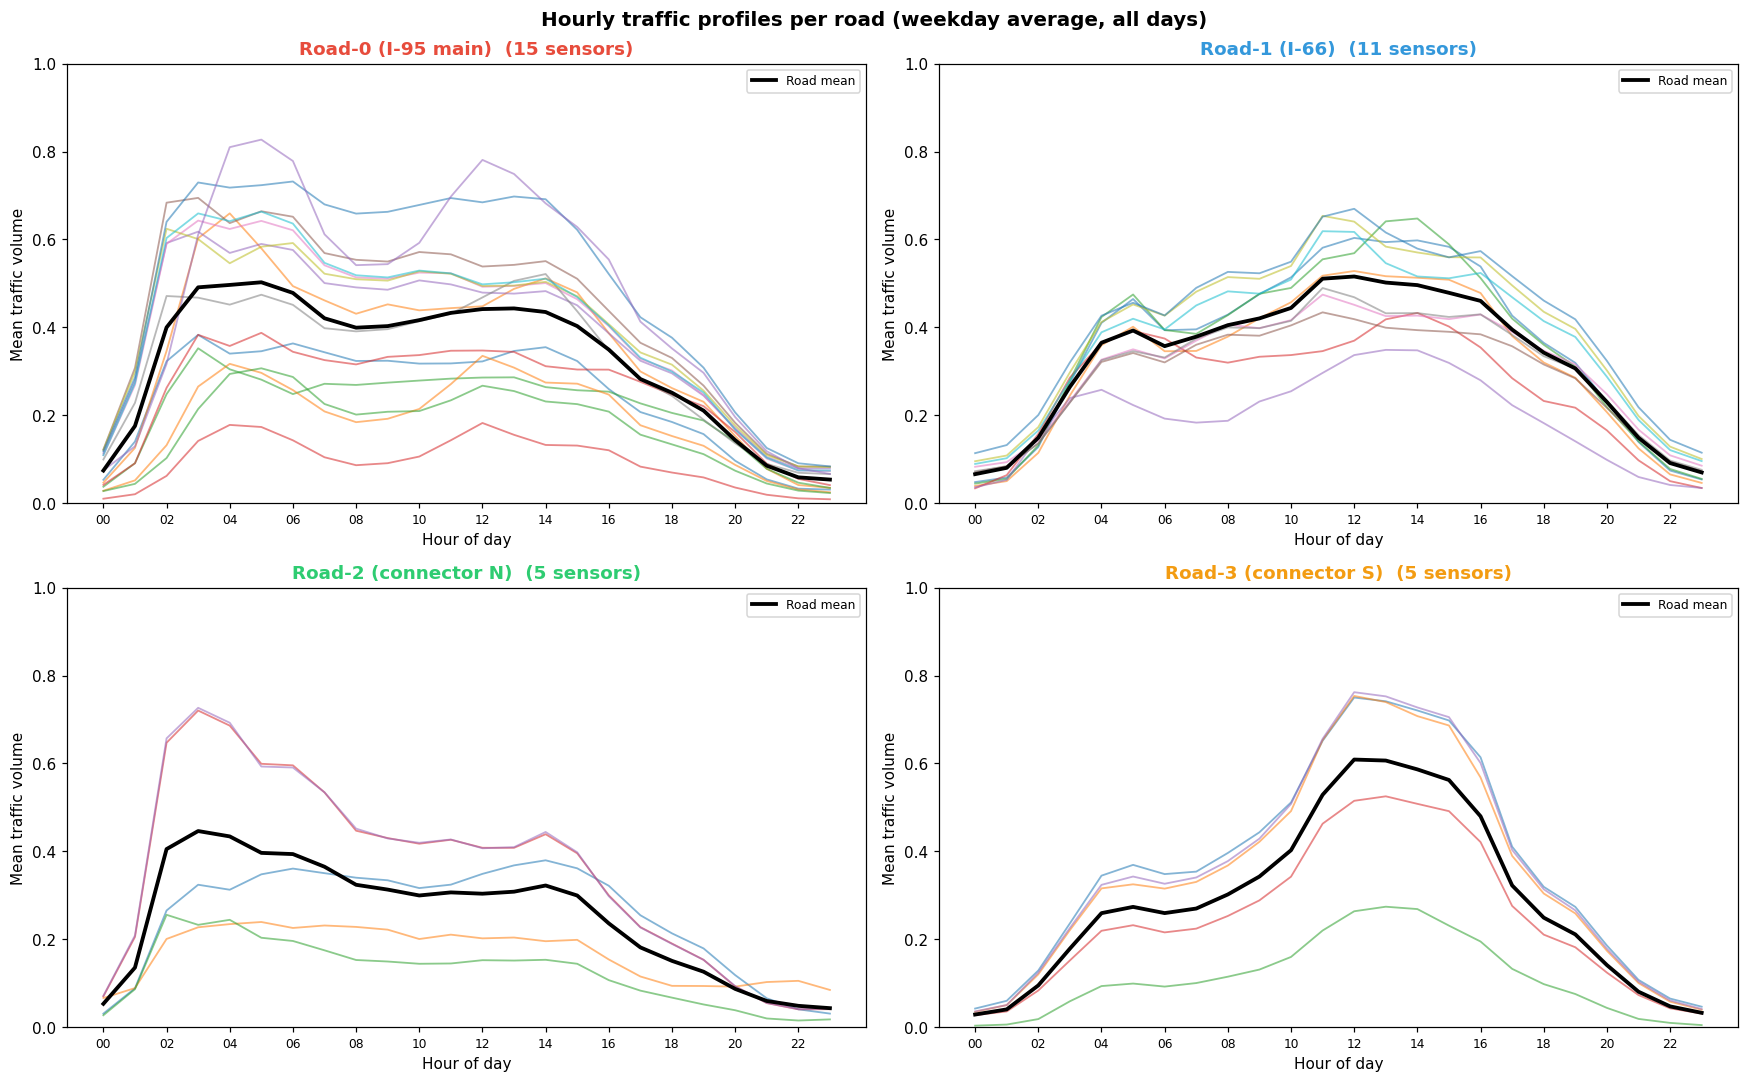

Saved road_profiles.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for r, ax in enumerate(axes.flat):
    mask = road_id == r
    if not mask.any():
        ax.axis('off'); continue
    sensor_idxs = np.where(mask)[0]
    road_typical = typical.mean(axis=0)[:, sensor_idxs]   # [24, n_road_sensors]
    for s_idx in range(road_typical.shape[1]):
        ax.plot(range(24), road_typical[:, s_idx], alpha=0.55, linewidth=1.2)
    ax.plot(range(24), road_typical.mean(axis=1), 'k-', linewidth=2.5, label='Road mean')
    ax.set_title(f"{ROAD_LABELS[r]}  ({mask.sum()} sensors)",
                 fontweight='bold', color=ROAD_COLORS[r])
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}' for h in range(0, 24, 2)], fontsize=8)
    ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean traffic volume')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('Hourly traffic profiles per road (weekday average, all days)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("road_profiles.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved road_profiles.png")
